# Initialize Notebook

In [1]:
import matplotlib.pyplot as plt
import torch
import os
from pathlib import Path
from importlib import reload
import numpy as np


os.chdir("..")  # Change root dir to project folder
print(os.getcwd())

import utils.paths as paths

/hs/fs08/data/group-brueggen/tmartinez/diffusion/src


# Prepare

Sampling Settings

In [106]:
# Model settings
denoiser = "LDM-Denoiser-WnetCC-v5"
denoiser_ckpt = "last-best"
vae = "VQ-VAE-256-DR3opt-FT"

# Sampling settings
device = "cuda:2"

# Image settings
sampling_steps = (2, 2)
batch_size = 1
seed = 42

Load scaler

In [3]:
from data.trf.scalers import LOFARScaler

scaler = LOFARScaler.load("LOFAR_scaler_II")

Load ICM Sampler

In [4]:
import models.diffusion.diffusion

reload(models.diffusion.diffusion)
import models.diffusion.sampler

reload(models.diffusion.sampler)
import models.ldm.swiit_config

reload(models.ldm.swiit_config)
import models.ldm.swiit_sampler

reload(models.ldm.swiit_sampler)
from models.ldm.swiit_sampler import SWIITSampler

swiit_sampler = SWIITSampler(
    denoiser=denoiser,
    denoiser_ckpt=denoiser_ckpt,
    vae=vae,
    device=device,
)

/hs/fs08/data/group-brueggen/tmartinez/envs/cenv_diffusion/lib/python3.11/site-packages/stringcolor/main.py:11: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
 10:57:07 (SWIITSampler) - INFO : No config provided, initializing default...
 10:57:07 (SWIITSampler) - INFO : Overriding config with provided kwargs...
 10:57:07 (SWIITSampler) - INFO : Loading model <LDM-Denoiser-WnetCC-v5> from checkpoint:
	best-train_step=00131999-val_loss=1.36963e+00.ckpt...
 10:57:11 (SWIITSampler) - INFO : Loading model <VQ-VAE-256-DR3opt-FT> from checkpoint:
	best-train_step=00460500-val_loss=1.56044e-01.ckpt...


VQLossWithDiscriminator running with hinge loss.


 10:57:11 (SWIITSampler) - INFO : Initializing diffusion sampler...
 10:57:11 (SWIITSampler) - INFO : ICM Sampler initialized.


# Prepare Sampling Inputs

## Text Context

In [136]:
import models.ldm.context_maps_utils
reload(models.ldm.context_maps_utils)
import models.ldm.context_maps
reload(models.ldm.context_maps)
from models.ldm.context_maps import text_to_context_map

text = "Te"
ctxt_map_text = text_to_context_map(
    text,
    ranges=((30, 60), (20, 30), (100, 300)),
    size_quadrants=(s + 1 for s in sampling_steps),
    px_separation=6,
    latent_size=swiit_sampler.config.latent_size,
)

 15:43:01 (ctxt_maps) - INFO : Creating text mask for 'Te' with font size auto and separation 6px.
 15:43:01 (ctxt_maps) - INFO : Applying dot pattern with separation 6px to text mask.
 15:43:01 (ctxt_maps) - INFO : Loading histogram data from 
	/storage/tmartinez/image_data/LOFAR/lotss_dr3_histogram3d_data.npz...
 15:43:01 (ctxt_maps) - INFO : Sampling context values from histogram for 170 sources...
 15:43:01 (ctxt_maps) - INFO : Creating context map...


## Seed Noise

In [109]:
torch.manual_seed(seed)
seed_noise_map = torch.randn(batch_size, 3, *ctxt_map_text.shape[-2:])

# Sample & Plot

## Sample

In [137]:
map_sampled, latent_sampled = swiit_sampler.sample(
    ctxt_map=ctxt_map_text,
    seed_noise_map=seed_noise_map,
    batch_size=batch_size,
    save_intermediates=False,
    timesteps=25,
    guidance_strength=0.2,
)

 15:43:04 (SWIITSampler) - INFO : Preparig context map...
 15:43:04 (SWIITSampler) - INFO : Adjusting sampling steps to (2, 2) to match context map size.
 15:43:04 (SWIITSampler) - INFO : 	Adding batch dimension.
 15:43:04 (SWIITSampler) - INFO : Making extended context map from context map by padding
 15:43:04 (SWIITSampler) - INFO : 	Expanding batch dimension.
 15:43:04 (SWIITSampler) - INFO : Sampling 2x2 steps with latent size 128 and image size 512


 15:43:04 (SWIITSampler) - INFO : --------------------------------------------------------------------------------

 15:43:04 (SWIITSampler) - INFO : Sample latent map...


Sampling Latent Map:   0%|          | 0/4 [00:00<?, ?it/s]

Sampling...:   0%|          | 0/25 [00:00<?, ?it/s]

Sampling...:   0%|          | 0/25 [00:00<?, ?it/s]

Sampling...:   0%|          | 0/25 [00:00<?, ?it/s]

Sampling...:   0%|          | 0/25 [00:00<?, ?it/s]

 15:43:48 (SWIITSampler) - INFO : Sampling latents completed.


 15:43:48 (SWIITSampler) - INFO : --------------------------------------------------------------------------------

 15:43:48 (SWIITSampler) - INFO : Decoding latents...


Decoding latents:   0%|          | 0/4 [00:00<?, ?step/s]

## Plot

(<Figure size 500x500 with 1 Axes>, <Axes: >)

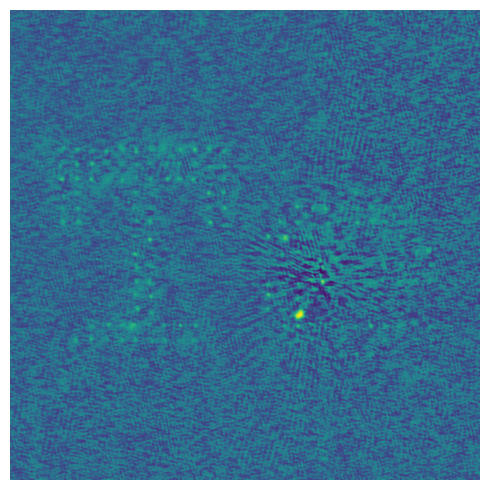

In [138]:
from plotting.images import plot_image_grid

plot_image_grid(
    map_sampled,
    n_cols=1,
)

# Create source property 3D histogram

Idea:
- Make 1d histogram for each fpeak, ftot, maj over entire source catalog.
    - Any one histogram can have its own appropriate range and binning
- Combine them to 3d histogram (np.histdd) with counts combined in 3d bins
- We can now sample from this 3d distribution:
    - Weight bins by inverse normalized count
    - sample uniformly from bin

## Load catalog

In [5]:
# Load LoTSS DR3 catalog
from data.utils import load_lotss_catalog

cols = [
    "Total_flux",
    "Peak_flux",
    "Maj",
]

lotss_cat = load_lotss_catalog(
    select_cols=cols,
    path=paths.LOFAR_DATA_PARENT_HOPPER / "LoTSS_DR3_v0.5.srl.parquet",
)

## Identify best 1d marginal bins

Get bins and counts:

In [6]:
from plotting.utils import auto_log_bins
from tqdm import tqdm


def auto_log_hist_min_count(data, num=10, min_count=20, maxiter=10, i=0):
    assert len(data) > 0, "Data array is empty."
    data = data[data > 0]  # Filter out non-positive values for log scale
    bins = np.geomspace(data.min(), data.max(), num=num + 1)
    counts, _ = np.histogram(data, bins=bins, density=False)
    # Filter out bins with counts below the threshold
    nonzero = counts >= min_count
    if not nonzero.any():
        raise ValueError("No bins have counts above the minimum threshold.")

    if i >= maxiter:
        print(f"Reached maximum iterations ({maxiter}). Returning current bins.")
        return bins, counts

    if not nonzero.all():
        print(
            f"Iteration {i}: range {bins[0]:.2e} - {bins[-1]:.2e}: {np.sum(~nonzero)} bins have counts below the threshold."
        )
        # Assuming unimodal distribution with strong center and weak tails
        median = np.median(data)
        invalid_bins_lo = bins[:-1][~nonzero]
        invalid_bins_hi = bins[1:][~nonzero]
        print(f"Median value: {median:.2e}")
        lower_limit = (
            invalid_bins_hi[invalid_bins_hi < median].max()
            if np.any(invalid_bins_hi < median)
            else bins[0]
        )
        upper_limit = (
            invalid_bins_lo[invalid_bins_lo > median].min()
            if np.any(invalid_bins_lo > median)
            else bins[-1]
        )
        print(
            f"Refining range to {lower_limit:.2e} - {upper_limit:.2e} for next iteration."
        )
        valid_range = (data >= lower_limit) & (data <= upper_limit)
        bins, counts = auto_log_hist_min_count(
            data[valid_range], num=num, min_count=min_count, maxiter=maxiter, i=i + 1
        )
    return bins, counts


n_bins = 250
min_count = 100
hist_dict = {}
for col in tqdm(cols):
    v = lotss_cat[col].values
    bins, counts = auto_log_hist_min_count(
        v, num=n_bins, min_count=min_count, maxiter=50
    )
    hist_dict[col] = (counts, bins)

  0%|          | 0/3 [00:00<?, ?it/s]

Iteration 0: range 5.30e-05 - 2.71e+05: 123 bins have counts below the threshold.
Median value: 9.78e-01
Refining range to 8.87e-02 - 7.58e+03 for next iteration.
Iteration 1: range 8.88e-02 - 7.58e+03: 9 bins have counts below the threshold.
Median value: 9.78e-01
Refining range to 9.72e-02 - 5.51e+03 for next iteration.


 33%|███▎      | 1/3 [00:03<00:06,  3.42s/it]

Iteration 0: range 2.69e-87 - 6.05e+04: 234 bins have counts below the threshold.
Median value: 5.15e-01
Refining range to 1.60e-02 - 1.12e+04 for next iteration.
Iteration 1: range 1.91e-02 - 1.12e+04: 38 bins have counts below the threshold.
Median value: 5.15e-01
Refining range to 3.08e-02 - 2.40e+03 for next iteration.
Iteration 2: range 3.08e-02 - 2.40e+03: 3 bins have counts below the threshold.
Median value: 5.15e-01
Refining range to 3.08e-02 - 2.00e+03 for next iteration.


 67%|██████▋   | 2/3 [00:08<00:04,  4.13s/it]

Iteration 0: range 1.97e-01 - 1.63e+03: 126 bins have counts below the threshold.
Median value: 8.90e+00
Refining range to 3.06e+00 - 2.68e+02 for next iteration.
Iteration 1: range 3.06e+00 - 2.68e+02: 37 bins have counts below the threshold.
Median value: 8.90e+00
Refining range to 4.37e+00 - 1.94e+02 for next iteration.
Iteration 2: range 4.37e+00 - 1.94e+02: 1 bins have counts below the threshold.
Median value: 8.90e+00
Refining range to 4.37e+00 - 1.91e+02 for next iteration.


100%|██████████| 3/3 [00:12<00:00,  4.22s/it]


Plot:

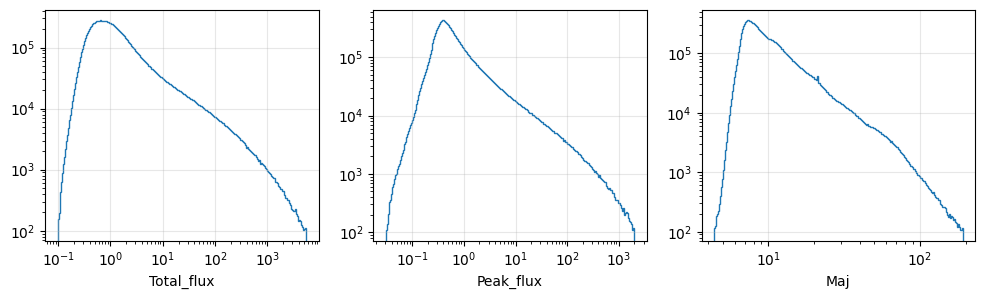

In [7]:
fig, axs = plt.subplots(1, 3, figsize=(12, 3))

for i, ax in enumerate(axs):
    col = cols[i]
    counts, bins = hist_dict[col]
    ax.stairs(counts, bins)
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel(col)
    ax.grid(alpha=0.3)
fig.show()

## Make 3d histogram

In [77]:
counts3d, bins_list = np.histogramdd(
    lotss_cat[cols].values,
    bins=[hist_dict[col][1] for col in cols],
)
bins_arr = np.array(bins_list)

In [78]:
bins_arr.shape, counts3d.shape

((3, 251), (250, 250, 250))

In [60]:
# Save histogram data for later use
import utils.paths as paths
np.savez(
    paths.LOFAR_DATA_PARENT_HOPPER / "lotss_dr3_histogram3d_data.npz",
    counts3d=counts3d,
    bins_arr=bins_arr,
)

/tmp/ipykernel_2371803/2207187003.py:4: RuntimeWarning: divide by zero encountered in log
  ax.pcolormesh(bins_arr[pidx1], bins_arr[pidx2], np.log(counts3d.sum(axis=sum_idx)))


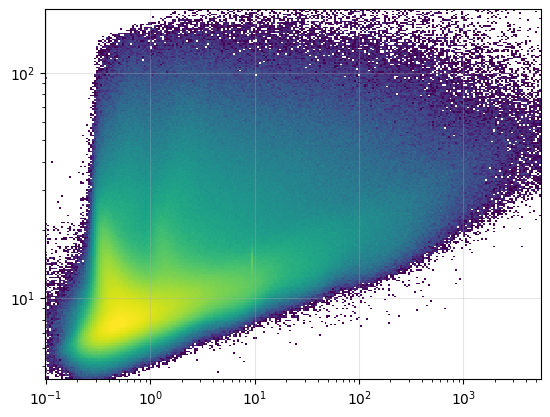

In [66]:
fig, ax = plt.subplots()
plot_idxs = pidx1, pidx2 = 0, 2
sum_idx = (set((0, 1, 2)) - set(plot_idxs)).pop()
ax.pcolormesh(bins_arr[pidx1], bins_arr[pidx2], np.log(counts3d.sum(axis=sum_idx)))
ax.set_xscale("log")
ax.set_yscale("log")
# ax.axline((0, 0), (1, 1), color="red", linestyle="--")
ax.grid(alpha=0.3)

## Function for sampling:

100000 3 ((30, 60), None, (10, 30))


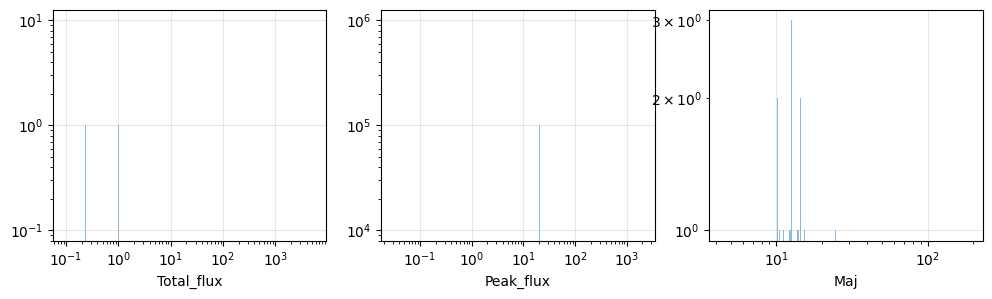

In [129]:
import models.ldm.context_maps_utils
reload(models.ldm.context_maps_utils)
import models.ldm.context_maps
reload(models.ldm.context_maps)
from models.ldm.context_maps_utils import sample_histdd

samples = sample_histdd(
    counts3d,
    bins_list,
    ranges=((30, 60), (20,), (10, 30)),
    n_samples=int(1e5),
)

fig, axs = plt.subplots(1, 3, figsize=(12, 3))

for i, ax in enumerate(axs):
    ax.hist(samples[:, i], bins=bins_arr[i], density=False, alpha=0.5, label="Sampled")
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel(cols[i])
    ax.grid(alpha=0.3)
fig.show()

In [130]:
samples.shape

(100000, 3)

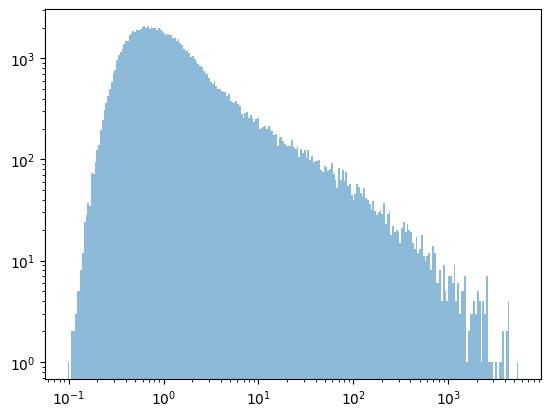

In [18]:
# Simple test: Try to recover individual marginal distributions
n_samples = int(1e5)
seed_values = sample_histdd(
    counts3d, bins_arr, n_samples=n_samples
)

fig, ax = plt.subplots(1, 1)
ax.hist(seed_values[:, 0], bins=bins_arr[0], density=False, alpha=0.5, label="Sampled")
ax.set_yscale("log")
ax.set_xscale("log")
plt.show()

Preparing...
Computing fixed bin indices for 1 fixed axes...
Computing marginal counts...
Sampling free axes...


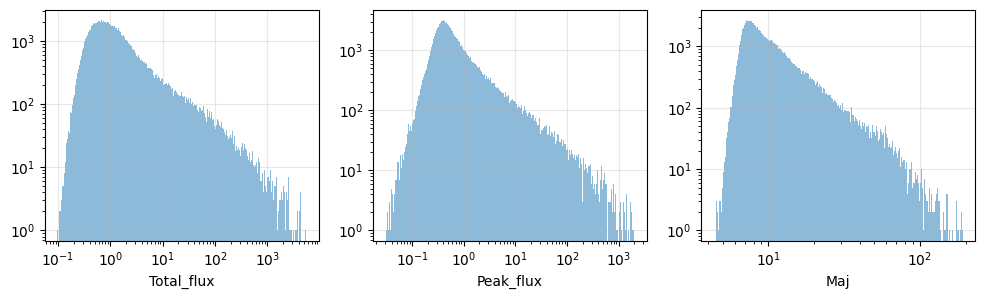

In [57]:
samples = sample_histdd_marginal(
    counts3d, 
    bins_arr, 
    inputs=(seed_values[:, 0], None, None)
)

fig, axs = plt.subplots(1, 3, figsize=(12, 3))

for i, ax in enumerate(axs):
    ax.hist(samples[:, i], bins=bins_arr[i], density=False, alpha=0.5, label="Sampled")
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel(cols[i])
    ax.grid(alpha=0.3)
fig.show()

In [ ]:
import itertools


def sample_histNd(counts, bins_arr, n_samples=1000):
    assert (
        bins_arr.shape[0] == counts.ndim
    ), "Number of different sets of bins must match number of dimensions"
    centers = 0.5 * (bins_arr[:, :-1] + bins_arr[:, 1:])
    bin_width = centers[:, 1] - centers[:, 0]

    return samples